Nombres originales de columnas:
['Unnamed: 0', 'miles por galon', 'MOTOR', 'fuerza,caballos', 'peso,kg', 'modelo,año', 'acceleracion', 'pais', 'numero de cilindros', 'Unnamed: 9', 'Unnamed: 10']

Datos limpios: 391 observaciones
   mpg  motor  horsepower  weight  year  acceleration  cylinders
0   18    307         130    3504    70            12          8
1   15    350         165    3693    70            12          8
2   18    318         150    3436    70            11          8
3   16    304         150    3433    70            12          8
4   17    302         140    3449    70            11          8


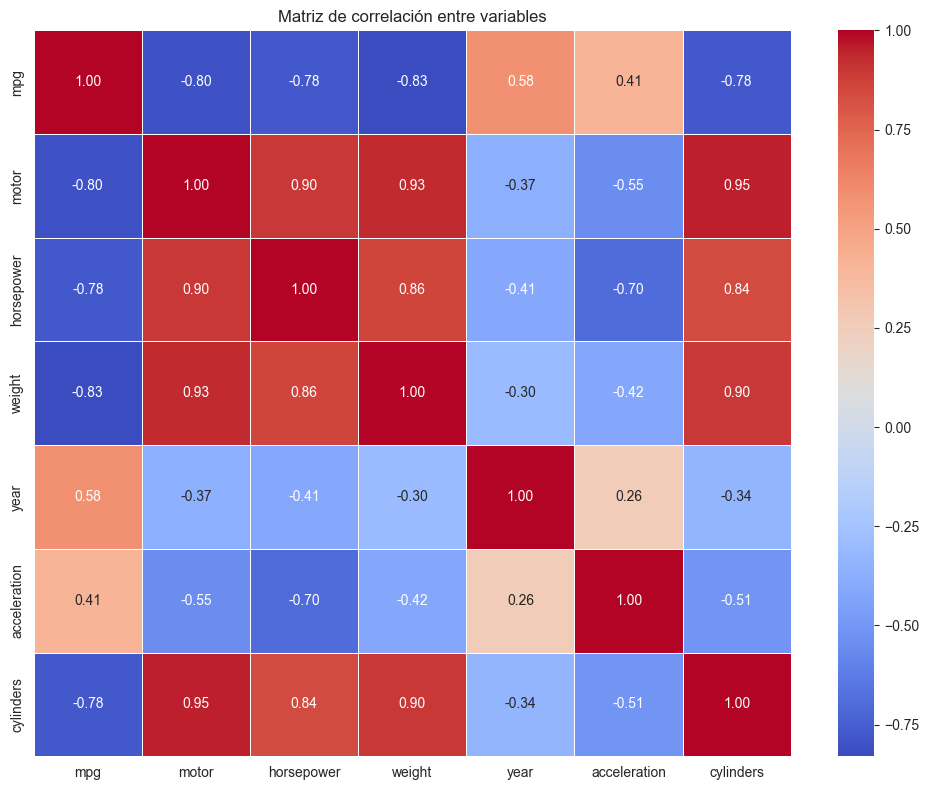

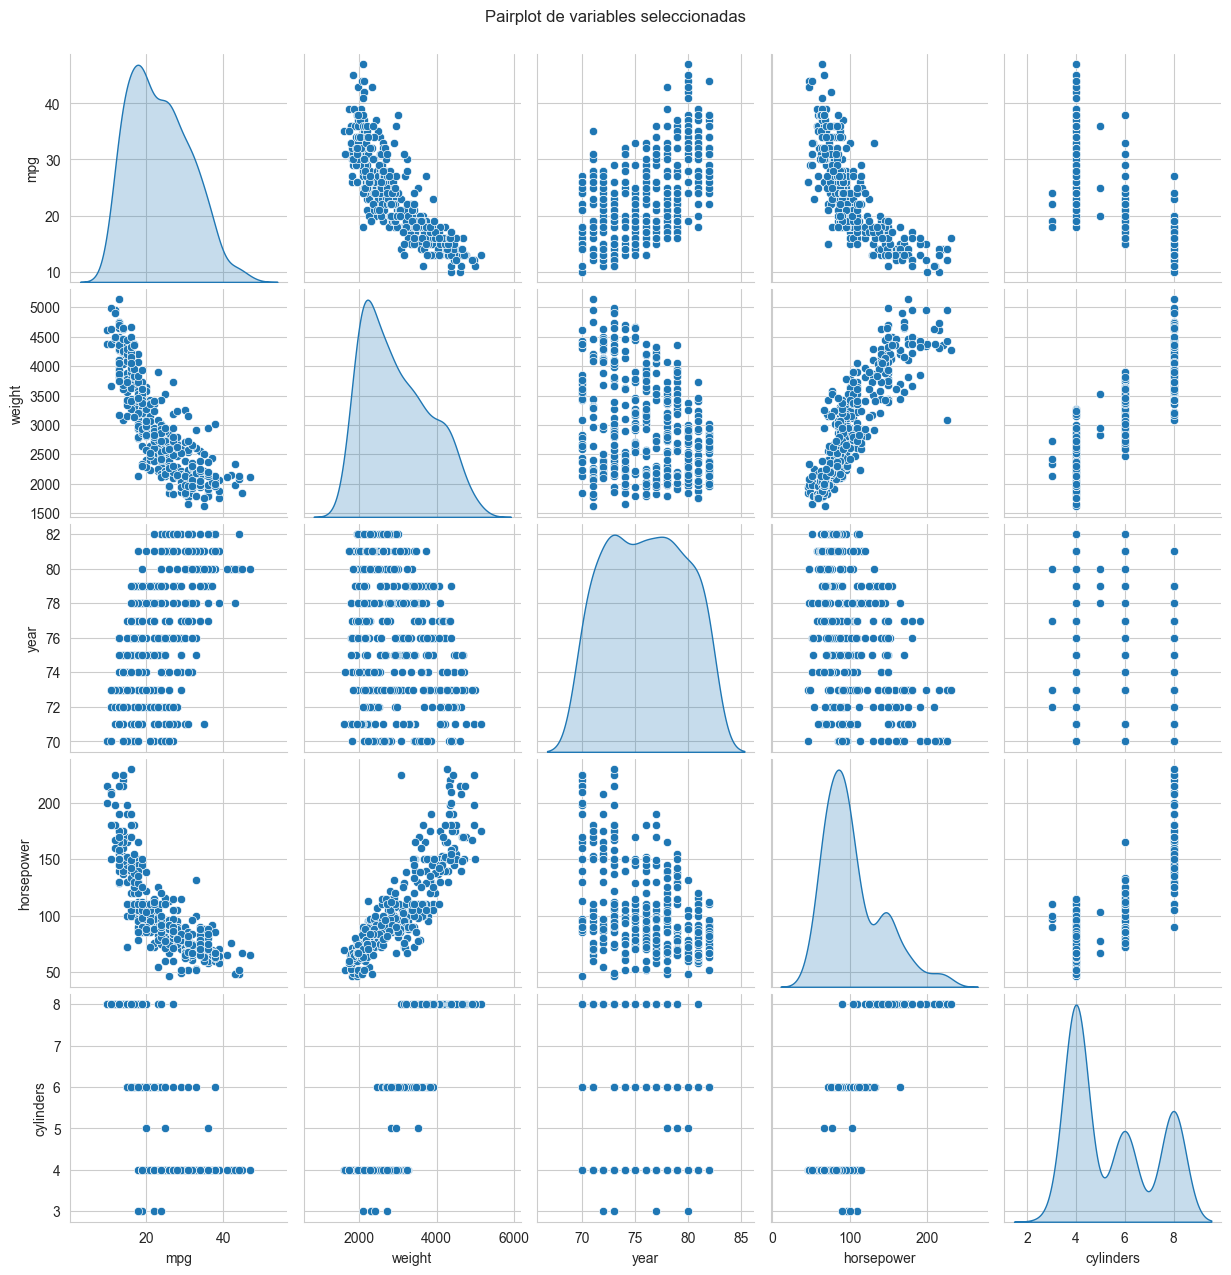


RESUMEN DEL MODELO
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     269.6
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.62e-134
Time:                        21:10:53   Log-Likelihood:                -1033.5
No. Observations:                 391   AIC:                             2081.
Df Residuals:                     384   BIC:                             2109.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -14.6318     

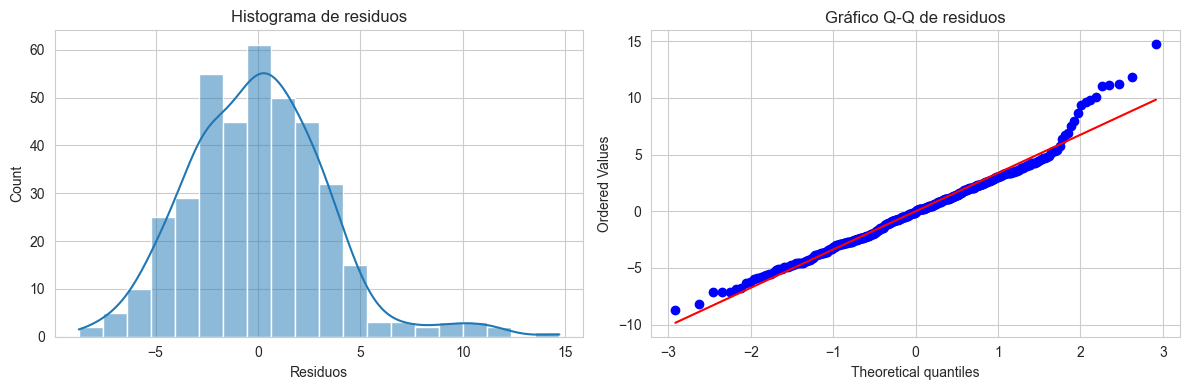


--- Independencia (Durbin-Watson) ---
DW = 1.2626


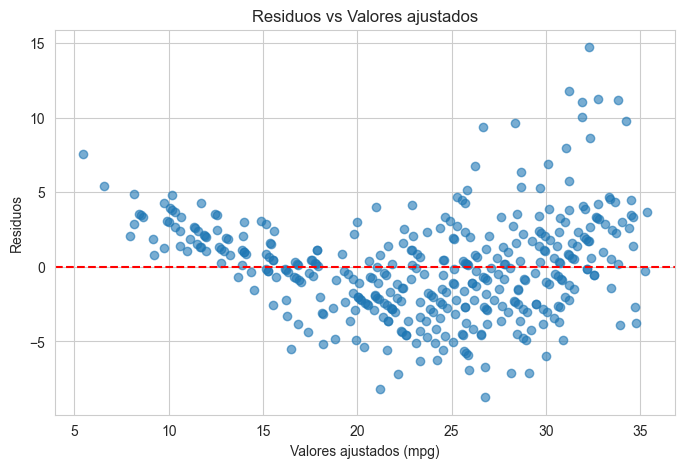


--- Multicolinealidad (VIF) ---
       Variable         VIF
2        weight  138.333366
5     cylinders  116.120254
4          year  110.907446
0         motor   89.041987
3  acceleration   69.076854
1    horsepower   60.341387


C:\Users\Ider Diaz\AppData\Local\Temp\ipykernel_1832\49971561.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_result, x='VIF', y='Variable', palette='Reds_r')


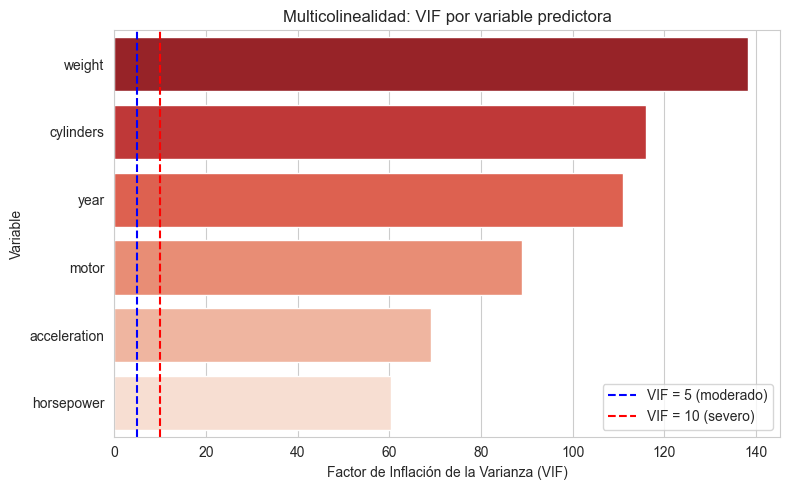

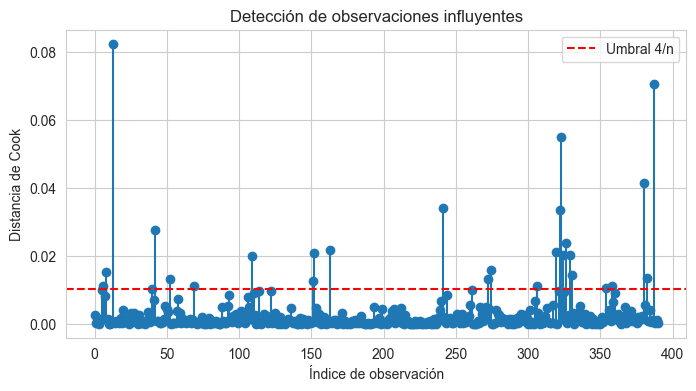


INTERPRETACIÓN DE RESULTADOS

1. Variable que más afecta el rendimiento (mpg): 'weight'
   Coeficiente estandarizado = -0.7378 (mayor magnitud)

2. Peso (weight): coeficiente = -0.0068, p-valor = 0.0000
   → El peso influye NEGATIVAMENTE en el rendimiento (mpg).
   → A mayor peso, menor mpg → MAYOR consumo de combustible.

3. Año (year): coeficiente = 0.7621, p-valor = 0.0000
   → SÍ, los carros más nuevos consumen MENOS combustible.
   → Por cada año adicional, mpg aumenta en 0.7621 unidades.

4. R² = 0.8081 | R² ajustado = 0.8051
   → El modelo explica el 80.8% de la variabilidad en mpg.

Análisis completado. Figuras guardadas:
 - mapa_calor_correlacion.png
 - pairplot.png
 - normalidad_residuos.png
 - homocedasticidad.png
 - vif_barras.png
 - cooks_distance.png


In [3]:
# ============================================================
# Regresión Lineal Múltiple - Datos de Automóviles
# Archivo: analisis_carros.py
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, probplot
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------
# 1. Cargar y limpiar datos
# ------------------------------------------------------------
df = pd.read_csv('Carros - DATOS.csv', encoding='utf-8')

# Eliminar la fila que contiene "DATOS LIMPIOS" (si existe)
df = df[~df.iloc[:, 1].astype(str).str.contains('DATOS LIMPIOS', na=False)]

# Mostrar nombres originales de las columnas (para que usted pueda verificar)
print("Nombres originales de columnas:")
print(df.columns.tolist())

# ------------------------------------------------------------
# RENOMBRADO DE COLUMNAS (AJUSTE SEGÚN SU ARCHIVO)
# ------------------------------------------------------------
# Según la estructura típica del archivo, los índices son:
# índice 0: columna vacía (índice)
# índice 1: 'miles por galon'
# índice 2: 'MOTOR'
# índice 3: 'fuerza,caballos'
# índice 4: 'peso,kg'
# índice 5: 'modelo,año'
# índice 6: 'acceleracion'
# índice 8: 'numero de cilindros'
# Si los nombres son diferentes, cambie los textos de la izquierda en el diccionario.

columnas_orig = df.columns.tolist()
renombres = {
    columnas_orig[1]: 'mpg',
    columnas_orig[2]: 'motor',
    columnas_orig[3]: 'horsepower',
    columnas_orig[4]: 'weight',
    columnas_orig[5]: 'year',
    columnas_orig[6]: 'acceleration',
    columnas_orig[8]: 'cylinders'
}
df = df.rename(columns=renombres)

# Seleccionar solo las variables de interés
variables = ['mpg', 'motor', 'horsepower', 'weight', 'year', 'acceleration', 'cylinders']
df = df[variables].copy()

# Convertir a numérico (forzar)
for col in variables:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar filas con valores nulos (si los hay)
df = df.dropna()
print(f"\nDatos limpios: {df.shape[0]} observaciones")
print(df.head())

# ------------------------------------------------------------
# 2. Gráficos exploratorios
# ------------------------------------------------------------
# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación entre variables')
plt.tight_layout()
plt.savefig('mapa_calor_correlacion.png', dpi=150)
plt.show()

# Pairplot (solo algunas variables para no saturar)
sns.pairplot(df[['mpg', 'weight', 'year', 'horsepower', 'cylinders']], diag_kind='kde')
plt.suptitle('Pairplot de variables seleccionadas', y=1.02)
plt.savefig('pairplot.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 3. Modelo de regresión lineal múltiple
# ------------------------------------------------------------
X = df[['motor', 'horsepower', 'weight', 'acceleration', 'year', 'cylinders']]
y = df['mpg']
X_const = sm.add_constant(X)

modelo = sm.OLS(y, X_const).fit()
print("\n" + "="*70)
print("RESUMEN DEL MODELO")
print("="*70)
print(modelo.summary())

# Tabla de coeficientes
coef_tabla = pd.DataFrame({
    'Coeficiente β': modelo.params,
    'Error estándar': modelo.bse,
    'p-valor': modelo.pvalues,
    'IC 95% inferior': modelo.conf_int()[0],
    'IC 95% superior': modelo.conf_int()[1]
})
print("\nCoeficientes e intervalos de confianza (95%):")
print(coef_tabla)

# Coeficientes estandarizados (betas)
def beta_std(modelo, X, y):
    y_std = (y - y.mean()) / y.std()
    X_std = (X - X.mean()) / X.std()
    X_std_const = sm.add_constant(X_std)
    modelo_std = sm.OLS(y_std, X_std_const).fit()
    return modelo_std.params.drop('const')

coef_std = beta_std(modelo, X, y)
print("\nCoeficientes estandarizados (importancia relativa):")
print(coef_std.sort_values(key=abs, ascending=False))

# ------------------------------------------------------------
# 4. Verificación de supuestos
# ------------------------------------------------------------
residuos = modelo.resid
ajustados = modelo.fittedvalues

# a) Normalidad
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"\n--- Normalidad (Shapiro-Wilk) ---")
print(f"Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")

# Gráficos de normalidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title("Histograma de residuos")
axes[0].set_xlabel("Residuos")
probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Gráfico Q-Q de residuos")
plt.tight_layout()
plt.savefig('normalidad_residuos.png', dpi=150)
plt.show()

# b) Independencia (Durbin-Watson)
dw = durbin_watson(residuos)
print(f"\n--- Independencia (Durbin-Watson) ---")
print(f"DW = {dw:.4f}")

# c) Homocedasticidad
plt.figure(figsize=(8,5))
plt.scatter(ajustados, residuos, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores ajustados (mpg)")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores ajustados")
plt.savefig('homocedasticidad.png', dpi=150)
plt.show()

# d) Multicolinealidad (VIF)
def calcular_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values("VIF", ascending=False)

vif_result = calcular_vif(X)
print("\n--- Multicolinealidad (VIF) ---")
print(vif_result)

# Gráfico de barras VIF
plt.figure(figsize=(8,5))
sns.barplot(data=vif_result, x='VIF', y='Variable', palette='Reds_r')
plt.axvline(x=5, color='blue', linestyle='--', label='VIF = 5 (moderado)')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (severo)')
plt.xlabel("Factor de Inflación de la Varianza (VIF)")
plt.title("Multicolinealidad: VIF por variable predictora")
plt.legend()
plt.tight_layout()
plt.savefig('vif_barras.png', dpi=150)
plt.show()

# e) Distancia de Cook (puntos influyentes)
influence = modelo.get_influence()
cooks_d = influence.cooks_distance[0]
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt='o', basefmt=' ')
plt.axhline(y=4/len(cooks_d), color='red', linestyle='--', label='Umbral 4/n')
plt.xlabel("Índice de observación")
plt.ylabel("Distancia de Cook")
plt.title("Detección de observaciones influyentes")
plt.legend()
plt.savefig('cooks_distance.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 5. Respuestas a preguntas específicas
# ------------------------------------------------------------
print("\n" + "="*70)
print("INTERPRETACIÓN DE RESULTADOS")
print("="*70)

# Variable más influyente
var_top = coef_std.abs().idxmax()
print(f"\n1. Variable que más afecta el rendimiento (mpg): '{var_top}'")
print(f"   Coeficiente estandarizado = {coef_std[var_top]:.4f} (mayor magnitud)")

# Peso
coef_w = modelo.params['weight']
p_w = modelo.pvalues['weight']
print(f"\n2. Peso (weight): coeficiente = {coef_w:.4f}, p-valor = {p_w:.4f}")
if coef_w < 0 and p_w < 0.05:
    print("   → El peso influye NEGATIVAMENTE en el rendimiento (mpg).")
    print("   → A mayor peso, menor mpg → MAYOR consumo de combustible.")
else:
    print("   → El peso no tiene efecto significativo o es positivo.")

# Año
coef_y = modelo.params['year']
p_y = modelo.pvalues['year']
print(f"\n3. Año (year): coeficiente = {coef_y:.4f}, p-valor = {p_y:.4f}")
if coef_y > 0 and p_y < 0.05:
    print("   → SÍ, los carros más nuevos consumen MENOS combustible.")
    print(f"   → Por cada año adicional, mpg aumenta en {coef_y:.4f} unidades.")
else:
    print("   → No se confirma que los carros más nuevos consuman menos.")

print(f"\n4. R² = {modelo.rsquared:.4f} | R² ajustado = {modelo.rsquared_adj:.4f}")
print(f"   → El modelo explica el {modelo.rsquared*100:.1f}% de la variabilidad en mpg.")

print("\nAnálisis completado. Figuras guardadas:")
print(" - mapa_calor_correlacion.png")
print(" - pairplot.png")
print(" - normalidad_residuos.png")
print(" - homocedasticidad.png")
print(" - vif_barras.png")
print(" - cooks_distance.png")